# 8_3 — LLM-associated language intensity and student outcomes

This notebook produces the **main Figure 3** and the corresponding **Supplementary Information figures and tables** for the analysis of heterogeneity by LLM-associated language intensity.

It deliberately contains only publication-relevant analyses.

## Main specification

The LLM-associated word-rate measure is `rare_per_100`. A fixed decile variable is defined relative to the **pre-ChatGPT empirical distribution** and the same mapping is then applied to all submissions.

For each outcome, the main model is:

\[
Y^*_{ic}
=
\beta_1 Post_i
+
\beta_2 Decile_i
+
\beta_3(Post_i \times Decile_i)
+
\alpha_c
+
\epsilon_{ic},
\]

where \(Y^*\) is centered on the pre-ChatGPT mean and divided by the pre-ChatGPT standard deviation, \(\alpha_c\) denotes course fixed effects, and standard errors are CRV1 clustered by course.

**Figure 3A** reports \(\beta_3\), the change in the post-versus-pre difference associated with a one-decile increase in LLM-associated language.

**Figure 3B** reports the model-implied post-versus-pre contrast at each decile. Because the main model is linear in decile, these marginal contrasts are linear combinations of the estimated `after` and interaction coefficients. Confidence intervals use the same course-clustered model covariance matrix.

## Supplementary analyses

The notebook also produces:

1. a figure and table documenting the construction and pre/post composition of the fixed decile measure;
2. a categorical-decile robustness specification that relaxes the linearity assumption;
3. a raw-outcome version of the marginal-effects analysis using the same stored outcome variables as Figure 2;
4. full numerical tables for the standardized interaction models, standardized margins, and raw interaction models.

## Output convention

This notebook follows the same publication-output structure as `8_2`:

- the main Figure 3 is saved to `plots/`;
- `tables/` is reserved for main-paper tables if needed;
- all Supplementary Information figures, tables, and machine-readable SI outputs are saved to `appendix/`;
- every supplementary artifact uses an `SI_` filename prefix.


## Setup


In [2]:
#!pip install fastparquet pyfixest

In [3]:
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyfixest as pf


# ================================================================
# PATHS
# ================================================================

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"
OUTPUT_PATH = PROJECT_ROOT / "outputs"

ANALYSIS_DATA_PATH = (
    DATA_PATH
    / "analysis_data_public.parquet"
)

PLOT_PATH = (
    OUTPUT_PATH
    / "figures"
)

TABLE_PATH = (
    OUTPUT_PATH
    / "tables"
)

APPENDIX_PATH = (
    OUTPUT_PATH
    / "appendix"
)

for output_path in [
    PLOT_PATH,
    TABLE_PATH,
    APPENDIX_PATH,
]:
    output_path.mkdir(
        parents=True,
        exist_ok=True,
    )


# ================================================================
# IDENTIFIERS
# ================================================================

ID_COL = "bid"
COURSE_COL = "coursecode_clean"
RARE_COL = "rare_per_100"
GRADE_OUTCOME = "karakter_0_6"


# ================================================================
# OUTCOMES
# Same stored/raw outcomes as Figure 2
# ================================================================

OUTCOMES = {
    "WQ_index_norm": "Writing complexity",
    "readability_index_norm": "Readability",
    "lexical_index_norm": "Lexical complexity",
    "syntactic_index_norm": "Syntactic complexity",
    "cosine_similarity_full": "Text similarity",
    GRADE_OUTCOME: "Grade",
}

OUTCOME_ORDER = list(
    OUTCOMES.keys()
)


# ================================================================
# SHARED FIGURE DESIGN
# ================================================================

COLORS = {
    "before": "#4C78A8",
    "after": "#E45756",
    "reference": "#666666",
}

OUTCOME_COLORS = {
    "WQ_index_norm": "#B279A2",
    "readability_index_norm": "#4C78A8",
    "lexical_index_norm": "#72B7B2",
    "syntactic_index_norm": "#E45756",
    "cosine_similarity_full": "#F58518",
    GRADE_OUTCOME: "#333333",
}

OUTCOME_MARKERS = {
    "WQ_index_norm": "o",
    "readability_index_norm": "s",
    "lexical_index_norm": "^",
    "syntactic_index_norm": "D",
    "cosine_similarity_full": "P",
    GRADE_OUTCOME: "X",
}

PLOT_LABELS = {
    "WQ_index_norm": "Writing\ncomplexity",
    "readability_index_norm": "Readability",
    "lexical_index_norm": "Lexical\ncomplexity",
    "syntactic_index_norm": "Syntactic\ncomplexity",
    "cosine_similarity_full": "Text\nsimilarity",
    GRADE_OUTCOME: "Grade",
}

DECILE_GRID = list(
    range(1, 11)
)

DECILE_CENTER = 5.5


## Load and validate the final analytical sample


In [4]:
analysis_data = pd.read_parquet(
    ANALYSIS_DATA_PATH
)

required_cols = [
    ID_COL,
    COURSE_COL,
    "after",
    RARE_COL,
    *OUTCOME_ORDER,
]

missing_cols = [
    col
    for col in required_cols
    if col not in analysis_data.columns
]

if missing_cols:
    raise KeyError(
        "Final analytical dataset is missing required columns: "
        f"{missing_cols}"
    )

if analysis_data[ID_COL].duplicated().any():
    raise ValueError(
        "Final analytical dataset contains duplicate submission IDs."
    )

if not analysis_data["after"].isin([0, 1]).all():
    raise ValueError(
        "`after` must contain only 0/1."
    )

missing_values = (
    analysis_data[
        required_cols
    ]
    .isna()
    .sum()
)

if missing_values.any():
    raise ValueError(
        "Missing values in analysis-required columns:\n"
        + missing_values.loc[
            missing_values > 0
        ].to_string()
    )

course_period_support = (
    analysis_data
    .groupby(COURSE_COL)["after"]
    .nunique()
)

if (course_period_support < 2).any():
    raise ValueError(
        "The final analytical sample contains courses that "
        "do not span both pre- and post-ChatGPT periods."
    )

analysis_data = (
    analysis_data
    .copy()
)

pre_mask = (
    analysis_data["after"]
    == 0
)

post_mask = (
    analysis_data["after"]
    == 1
)

print(
    f"Analytical submissions: {len(analysis_data):,}"
)

print(
    f"Pre-ChatGPT: {pre_mask.sum():,}"
)

print(
    f"Post-ChatGPT: {post_mask.sum():,}"
)

print(
    f"Courses: {analysis_data[COURSE_COL].nunique():,}"
)


Analytical submissions: 44,374
Pre-ChatGPT: 32,911
Post-ChatGPT: 11,463
Courses: 479


## Construct the fixed pre-ChatGPT LLM-word decile

The decile variable is defined against the **pre-ChatGPT empirical cumulative distribution** of `rare_per_100`.

For any observed rare-word rate \(x\), the notebook computes its percentile position in the fixed pre-ChatGPT distribution and maps that percentile to deciles 1–10. The same mapping is applied to both pre- and post-ChatGPT observations.

This keeps the meaning of the intensity scale fixed over time. Because `rare_per_100` can contain ties, the realized pre-period shares need not be exactly 10% in every decile. The diagnostic table below makes this explicit.


In [5]:
pre_rare_sorted = np.sort(
    analysis_data.loc[
        pre_mask,
        RARE_COL,
    ].to_numpy()
)


def assign_pre_reference_decile(values):
    """
    Map values to deciles of the fixed pre-ChatGPT empirical CDF.

    Ties are kept together because observations with the same
    rare-word rate receive the same empirical CDF value.
    """

    values = np.asarray(
        values,
        dtype=float,
    )

    pre_cdf = (
        np.searchsorted(
            pre_rare_sorted,
            values,
            side="right",
        )
        / len(pre_rare_sorted)
    )

    decile = np.ceil(
        pre_cdf * 10
    ).astype(int)

    return np.clip(
        decile,
        1,
        10,
    )


analysis_data[
    "llm_decile"
] = assign_pre_reference_decile(
    analysis_data[
        RARE_COL
    ]
)


analysis_data[
    "llm_decile_c"
] = (
    analysis_data[
        "llm_decile"
    ]
    - DECILE_CENTER
)


support = (
    analysis_data
    .groupby(
        [
            "after",
            "llm_decile",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        index=[0, 1],
        columns=DECILE_GRID,
        fill_value=0,
    )
)

display(
    support
)

unsupported = [
    d
    for d in DECILE_GRID
    if (
        support.loc[0, d] == 0
        or support.loc[1, d] == 0
    )
]

if unsupported:
    raise ValueError(
        "The following fixed pre-reference deciles have no support "
        "in either the pre or post period: "
        f"{unsupported}. Inspect ties in rare_per_100 before proceeding."
    )


llm_decile,1,2,3,4,5,6,7,8,9,10
after,,,,,,,,,,
0,3291,3290,3290,3292,3290,3293,3290,3292,3291,3292
1,789,744,791,854,851,917,1076,1142,1336,2963


## SI Table — decile construction and sample composition

In [6]:
# ================================================================
# SI TABLE:
# FIXED DECILE CONSTRUCTION AND PRE/POST COMPOSITION
# ================================================================

composition_long = (
    analysis_data
    .groupby(
        [
            "after",
            "llm_decile",
        ],
        as_index=False,
    )
    .agg(
        n=(
            ID_COL,
            "size",
        ),
        mean_rare_rate=(
            RARE_COL,
            "mean",
        ),
        min_rare_rate=(
            RARE_COL,
            "min",
        ),
        max_rare_rate=(
            RARE_COL,
            "max",
        ),
    )
)

composition_long[
    "share_pct"
] = (
    composition_long[
        "n"
    ]
    / composition_long
      .groupby(
          "after"
      )[
          "n"
      ]
      .transform(
          "sum"
      )
    * 100
)


pre_comp = (
    composition_long
    .loc[
        composition_long[
            "after"
        ]
        == 0
    ]
    .set_index(
        "llm_decile"
    )
)

post_comp = (
    composition_long
    .loc[
        composition_long[
            "after"
        ]
        == 1
    ]
    .set_index(
        "llm_decile"
    )
)


table_s1 = pd.DataFrame(
    index=DECILE_GRID
)

table_s1.index.name = "llm_decile"

table_s1[
    "pre_min_rare_rate"
] = pre_comp[
    "min_rare_rate"
]

table_s1[
    "pre_max_rare_rate"
] = pre_comp[
    "max_rare_rate"
]

table_s1[
    "pre_mean_rare_rate"
] = pre_comp[
    "mean_rare_rate"
]

table_s1[
    "pre_n"
] = pre_comp[
    "n"
].astype(int)

table_s1[
    "pre_pct"
] = pre_comp[
    "share_pct"
]

table_s1[
    "post_mean_rare_rate"
] = post_comp[
    "mean_rare_rate"
]

table_s1[
    "post_n"
] = post_comp[
    "n"
].astype(int)

table_s1[
    "post_pct"
] = post_comp[
    "share_pct"
]


table_s1 = (
    table_s1
    .reset_index()
)


display(
    table_s1
)


table_s1.to_csv(
    APPENDIX_PATH
    / "SI_llm_decile_construction_composition.csv",
    index=False,
)


with open(
    APPENDIX_PATH
    / "SI_llm_decile_construction_composition.tex",
    "w",
    encoding="utf-8",
) as f:

    f.write(
        table_s1.to_latex(
            index=False,
            float_format="%.3f",
            caption=(
                "Construction and sample composition of the fixed "
                "pre-ChatGPT LLM-associated word-rate deciles."
            ),
            label="tab:llm_decile_composition",
        )
    )


,llm_decile,pre_min_rare_rate,pre_max_rare_rate,pre_mean_rare_rate,pre_n,pre_pct,post_mean_rare_rate,post_n,post_pct
0,1,0.000000,0.069979,0.027231,3291,9.999696,0.026591,789,6.883015
1,2,0.070012,0.127137,0.099796,3290,9.996658,0.100559,744,6.490448
2,3,0.127146,0.173870,0.151078,3290,9.996658,0.151194,791,6.900462
3,4,0.173913,0.222717,0.198390,3292,10.002735,0.198589,854,7.450057
4,5,0.222717,0.271665,0.246912,3290,9.996658,0.247141,851,7.423886
5,6,0.271739,0.325818,0.298193,3293,10.005773,0.297673,917,7.999651
6,7,0.325829,0.389940,0.356508,3290,9.996658,0.357110,1076,9.386722
7,8,0.389972,0.474608,0.429156,3292,10.002735,0.431051,1142,9.962488
8,9,0.474618,0.609358,0.534831,3291,9.999696,0.536957,1336,11.654890
9,10,0.609377,3.415941,0.835382,3292,10.002735,1.131406,2963,25.848382


## SI Figure — construction and composition of the fixed decile measure

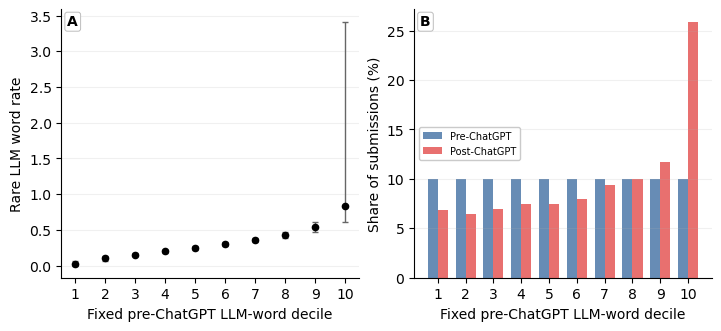

In [7]:
# ================================================================
# SI FIGURE:
# DECILE CONSTRUCTION AND PRE/POST COMPOSITION
# ================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.1, 3.2),
    layout="constrained",
)


ax = axes[0]

pre_plot = (
    table_s1
    .sort_values(
        "llm_decile"
    )
)

x = (
    pre_plot[
        "llm_decile"
    ]
    .to_numpy()
)

y = (
    pre_plot[
        "pre_mean_rare_rate"
    ]
    .to_numpy()
)

yerr = np.vstack(
    [
        y
        - pre_plot[
            "pre_min_rare_rate"
        ].to_numpy(),

        pre_plot[
            "pre_max_rare_rate"
        ].to_numpy()
        - y,
    ]
)

ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o",
    linestyle="none",
    color="black",
    ecolor=COLORS[
        "reference"
    ],
    markersize=4.5,
    elinewidth=1.0,
    capsize=2.0,
)

ax.set_xticks(
    DECILE_GRID
)

ax.set_xlabel(
    "Fixed pre-ChatGPT LLM-word decile"
)

ax.set_ylabel(
    "Rare LLM word rate"
)

ax.grid(
    axis="y",
    alpha=0.18,
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

ax.text(
    0.02,
    0.98,
    "A",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.18",
        "facecolor": "white",
        "edgecolor": "#BDBDBD",
        "linewidth": 0.7,
    },
)


ax = axes[1]

width = 0.36

pre_pct = (
    table_s1[
        "pre_pct"
    ]
    .to_numpy()
)

post_pct = (
    table_s1[
        "post_pct"
    ]
    .to_numpy()
)

ax.bar(
    x - width / 2,
    pre_pct,
    width=width,
    color=COLORS[
        "before"
    ],
    alpha=0.85,
    label="Pre-ChatGPT",
)

ax.bar(
    x + width / 2,
    post_pct,
    width=width,
    color=COLORS[
        "after"
    ],
    alpha=0.85,
    label="Post-ChatGPT",
)

ax.set_xticks(
    DECILE_GRID
)

ax.set_xlabel(
    "Fixed pre-ChatGPT LLM-word decile"
)

ax.set_ylabel(
    "Share of submissions (%)"
)

ax.grid(
    axis="y",
    alpha=0.18,
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#C8C8C8",
    framealpha=0.95,
    fontsize=7,
)

ax.text(
    0.02,
    0.98,
    "B",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.18",
        "facecolor": "white",
        "edgecolor": "#BDBDBD",
        "linewidth": 0.7,
    },
)


fig.savefig(
    APPENDIX_PATH
    / "SI_llm_decile_construction_composition.pdf",
    bbox_inches="tight",
)

fig.savefig(
    APPENDIX_PATH
    / "SI_llm_decile_construction_composition.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()


## Standardize outcomes using the pre-ChatGPT distribution


In [8]:
# ================================================================
# PRE-CHATGPT STANDARDIZATION
# ================================================================

STANDARDIZED_OUTCOMES = {}
standardization_rows = []


for outcome, label in OUTCOMES.items():

    pre_mean = (
        analysis_data
        .loc[
            pre_mask,
            outcome,
        ]
        .mean()
    )

    pre_sd = (
        analysis_data
        .loc[
            pre_mask,
            outcome,
        ]
        .std(
            ddof=1
        )
    )

    if (
        not np.isfinite(pre_sd)
        or pre_sd <= 0
    ):
        raise ValueError(
            f"Invalid pre-ChatGPT SD for {outcome}: {pre_sd}"
        )

    std_col = (
        f"{outcome}__pre_sd"
    )

    analysis_data[
        std_col
    ] = (
        analysis_data[
            outcome
        ]
        - pre_mean
    ) / pre_sd

    STANDARDIZED_OUTCOMES[
        outcome
    ] = std_col

    standardization_rows.append(
        {
            "outcome": outcome,
            "label": label,
            "pre_mean": pre_mean,
            "pre_sd": pre_sd,
            "standardized_column": std_col,
        }
    )


standardization_table = pd.DataFrame(
    standardization_rows
)

display(
    standardization_table
)


,outcome,label,pre_mean,pre_sd,standardized_column
0,WQ_index_norm,Writing complexity,0.455603,0.111435,WQ_index_norm__pre_sd
1,readability_index_norm,Readability,0.461913,0.108668,readability_index_norm__pre_sd
2,lexical_index_norm,Lexical complexity,0.455374,0.112898,lexical_index_norm__pre_sd
3,syntactic_index_norm,Syntactic complexity,0.446820,0.114894,syntactic_index_norm__pre_sd
4,cosine_similarity_full,Text similarity,0.658896,0.196176,cosine_similarity_full__pre_sd
5,karakter_0_6,Grade,4.509951,1.273488,karakter_0_6__pre_sd


## Helper functions for model extraction and margins

For the main linear interaction model, the post-versus-pre contrast at decile \(d\) is

\[
\hat\beta_{\mathrm{after}}
+
(d-5.5)
\hat\beta_{\mathrm{after}\times\mathrm{decile}}.
\]

The variance is obtained from the full CRV1 coefficient covariance matrix, including the covariance between the `after` coefficient and the interaction coefficient. The confidence-limit critical value is recovered from the fitted model so that the margins use the same finite-sample inference convention as the underlying PyFixest model.


In [9]:
def find_interaction_term(
    tidy_table,
    variable_a,
    variable_b,
):
    """Find a two-way interaction term regardless of term order."""

    for term in tidy_table.index:

        pieces = (
            str(term)
            .replace(" ", "")
            .split(":")
        )

        if (
            len(pieces) == 2
            and set(pieces)
            == {
                variable_a,
                variable_b,
            }
        ):
            return term

    raise KeyError(
        f"Could not find interaction between "
        f"{variable_a} and {variable_b}. "
        f"Terms: {list(tidy_table.index)}"
    )


def get_model_vcov(
    model,
    tidy_table,
):
    """
    Return the coefficient covariance matrix as a labeled DataFrame.
    """

    vcov = getattr(
        model,
        "_vcov",
        None,
    )

    if vcov is None:
        raise AttributeError(
            "Could not access the fitted PyFixest covariance matrix "
            "through model._vcov."
        )

    if isinstance(
        vcov,
        pd.DataFrame,
    ):
        return (
            vcov
            .loc[
                tidy_table.index,
                tidy_table.index,
            ]
        )

    coef_names = getattr(
        model,
        "_coefnames",
        None,
    )

    if (
        coef_names is None
        or len(coef_names)
        != np.asarray(vcov).shape[0]
    ):
        coef_names = list(
            tidy_table.index
        )

    vcov_df = pd.DataFrame(
        np.asarray(vcov),
        index=coef_names,
        columns=coef_names,
    )

    return (
        vcov_df
        .loc[
            tidy_table.index,
            tidy_table.index,
        ]
    )


def model_critical_value(
    tidy_table,
):
    """
    Recover the two-sided confidence-limit critical value
    used by the fitted model.
    """

    candidates = []

    for _, row in tidy_table.iterrows():

        se = row[
            "Std. Error"
        ]

        if (
            np.isfinite(se)
            and se > 0
        ):
            candidates.append(
                (
                    row["97.5%"]
                    - row["Estimate"]
                )
                / se
            )

    if not candidates:
        raise ValueError(
            "Could not recover the model's confidence-interval "
            "critical value."
        )

    return float(
        np.nanmedian(
            candidates
        )
    )


def linear_post_pre_margins(
    model,
    deciles=DECILE_GRID,
    center=DECILE_CENTER,
):
    """
    Model-implied post-versus-pre contrasts across a numeric decile.

    This is algebraically equivalent to prediction-based margins for
    the present linear interaction model.
    """

    tidy = (
        model
        .tidy()
    )

    vcov = get_model_vcov(
        model,
        tidy,
    )

    interaction_term = find_interaction_term(
        tidy,
        "after",
        "llm_decile_c",
    )

    b_after = tidy.loc[
        "after",
        "Estimate",
    ]

    b_interaction = tidy.loc[
        interaction_term,
        "Estimate",
    ]

    crit = model_critical_value(
        tidy
    )

    rows = []

    for decile in deciles:

        x = (
            decile
            - center
        )

        estimate = (
            b_after
            + x
            * b_interaction
        )

        variance = (
            vcov.loc[
                "after",
                "after",
            ]
            + x ** 2
            * vcov.loc[
                interaction_term,
                interaction_term,
            ]
            + 2
            * x
            * vcov.loc[
                "after",
                interaction_term,
            ]
        )

        se = np.sqrt(
            max(
                variance,
                0,
            )
        )

        rows.append(
            {
                "decile": int(decile),
                "estimate": estimate,
                "std_error": se,
                "ci_low": (
                    estimate
                    - crit * se
                ),
                "ci_high": (
                    estimate
                    + crit * se
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


## Main linear interaction models


In [10]:
# ================================================================
# MAIN STANDARDIZED MODELS
# ================================================================

standardized_models = {}
interaction_rows = []


for outcome in OUTCOME_ORDER:

    std_col = (
        STANDARDIZED_OUTCOMES[
            outcome
        ]
    )

    model = pf.feols(
        (
            f"{std_col} ~ "
            f"after * llm_decile_c "
            f"| {COURSE_COL}"
        ),
        data=analysis_data,
        vcov={
            "CRV1": COURSE_COL
        },
    )

    standardized_models[
        outcome
    ] = model

    tidy = (
        model
        .tidy()
    )

    interaction_term = find_interaction_term(
        tidy,
        "after",
        "llm_decile_c",
    )

    row = tidy.loc[
        interaction_term
    ]

    interaction_rows.append(
        {
            "outcome": outcome,
            "label": OUTCOMES[
                outcome
            ],
            "estimate": row[
                "Estimate"
            ],
            "std_error": row[
                "Std. Error"
            ],
            "ci_low": row[
                "2.5%"
            ],
            "ci_high": row[
                "97.5%"
            ],
            "p_value": row[
                "Pr(>|t|)"
            ],
        }
    )


standardized_interactions = pd.DataFrame(
    interaction_rows
)

display(
    standardized_interactions
)


,outcome,label,estimate,std_error,ci_low,ci_high,p_value
0,WQ_index_norm,Writing complexity,0.013456,0.003160,0.007245,0.019666,2.489668e-05
1,readability_index_norm,Readability,0.019264,0.003408,0.012568,0.025961,2.719900e-08
2,lexical_index_norm,Lexical complexity,0.019609,0.003432,0.012865,0.026353,1.948952e-08
3,syntactic_index_norm,Syntactic complexity,-0.007754,0.004679,-0.016948,0.001440,9.814395e-02
4,cosine_similarity_full,Text similarity,-0.004348,0.003052,-0.010345,0.001649,1.549457e-01
5,karakter_0_6,Grade,-0.025599,0.004589,-0.034617,-0.016581,4.080673e-08


## Main-model marginal post–pre contrasts across deciles


In [11]:
# ================================================================
# MAIN STANDARDIZED MARGINS
# ================================================================

margin_rows = []


for outcome in OUTCOME_ORDER:

    temp = linear_post_pre_margins(
        standardized_models[
            outcome
        ]
    )

    temp[
        "outcome"
    ] = outcome

    temp[
        "label"
    ] = OUTCOMES[
        outcome
    ]

    margin_rows.append(
        temp
    )


standardized_margins = pd.concat(
    margin_rows,
    ignore_index=True,
)


display(
    standardized_margins
)


,decile,estimate,std_error,ci_low,ci_high,outcome,label
0,1,-0.044864,0.022224,-0.088532,-0.001196,WQ_index_norm,Writing complexity
1,2,-0.031409,0.019812,-0.070337,0.007520,WQ_index_norm,Writing complexity
2,3,-0.017953,0.017638,-0.052610,0.016704,WQ_index_norm,Writing complexity
3,4,-0.004498,0.015800,-0.035545,0.026549,WQ_index_norm,Writing complexity
4,5,0.008958,0.014429,-0.019394,0.037310,WQ_index_norm,Writing complexity
5,6,0.022413,0.013664,-0.004436,0.049263,WQ_index_norm,Writing complexity
6,7,0.035869,0.013609,0.009128,0.062611,WQ_index_norm,Writing complexity
7,8,0.049325,0.014272,0.021281,0.077368,WQ_index_norm,Writing complexity
8,9,0.062780,0.015561,0.032204,0.093356,WQ_index_norm,Writing complexity
9,10,0.076236,0.017337,0.042170,0.110301,WQ_index_norm,Writing complexity


## Figure 3 — interaction coefficients and marginal post–pre differences


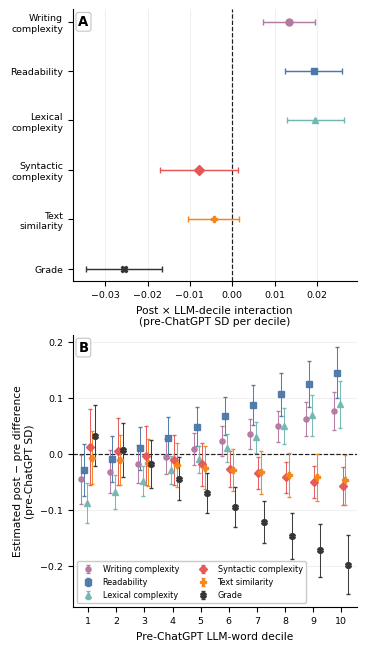

In [12]:
# ================================================================
# MAIN FIGURE 3
# A: POST × LLM-DECILE INTERACTION COEFFICIENTS
# B: MODEL-IMPLIED POST − PRE CONTRAST BY DECILE
# ================================================================

with plt.rc_context({
    "font.size": 7.0,
    "axes.labelsize": 7.7,
    "axes.titlesize": 8.0,
    "xtick.labelsize": 6.8,
    "ytick.labelsize": 6.8,
    "legend.fontsize": 5.8,
}):

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(3.55, 6.4),
        layout="constrained",
    )


    ax = axes[0]

    plot_a = (
        standardized_interactions
        .set_index(
            "outcome"
        )
        .loc[
            OUTCOME_ORDER
        ]
        .reset_index()
    )

    y_positions = np.arange(
        len(plot_a)
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.85,
        zorder=1,
    )

    for i, row in plot_a.iterrows():

        ax.errorbar(
            row[
                "estimate"
            ],
            i,
            xerr=[
                [
                    row[
                        "estimate"
                    ]
                    - row[
                        "ci_low"
                    ]
                ],
                [
                    row[
                        "ci_high"
                    ]
                    - row[
                        "estimate"
                    ]
                ],
            ],
            fmt=OUTCOME_MARKERS[
                row[
                    "outcome"
                ]
            ],
            linestyle="none",
            color=OUTCOME_COLORS[
                row[
                    "outcome"
                ]
            ],
            ecolor=OUTCOME_COLORS[
                row[
                    "outcome"
                ]
            ],
            markersize=5.0,
            elinewidth=1.05,
            capsize=2.2,
            zorder=3,
        )

    ax.set_yticks(
        y_positions
    )

    ax.set_yticklabels(
        [
            PLOT_LABELS[
                outcome
            ]
            for outcome
            in plot_a[
                "outcome"
            ]
        ]
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        (
            "Post × LLM-decile interaction\n"
            "(pre-ChatGPT SD per decile)"
        )
    )

    ax.grid(
        axis="x",
        alpha=0.18,
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.text(
        0.02,
        0.98,
        "A",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": "#BDBDBD",
            "linewidth": 0.7,
        },
    )


    ax = axes[1]

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.85,
        zorder=1,
    )

    offsets = np.linspace(
        -0.24,
        0.24,
        len(
            OUTCOME_ORDER
        ),
    )

    for offset, outcome in zip(
        offsets,
        OUTCOME_ORDER,
    ):

        temp = (
            standardized_margins
            .loc[
                standardized_margins[
                    "outcome"
                ]
                == outcome
            ]
            .sort_values(
                "decile"
            )
        )

        x = (
            temp[
                "decile"
            ]
            .to_numpy()
            + offset
        )

        y = (
            temp[
                "estimate"
            ]
            .to_numpy()
        )

        yerr = np.vstack(
            [
                y
                - temp[
                    "ci_low"
                ].to_numpy(),

                temp[
                    "ci_high"
                ].to_numpy()
                - y,
            ]
        )

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt=OUTCOME_MARKERS[
                outcome
            ],
            linestyle="none",
            color=OUTCOME_COLORS[
                outcome
            ],
            ecolor=OUTCOME_COLORS[
                outcome
            ],
            markersize=3.7,
            elinewidth=0.75,
            capsize=1.5,
            alpha=0.95,
            label=OUTCOMES[
                outcome
            ],
            zorder=3,
        )

    ax.set_xticks(
        DECILE_GRID
    )

    ax.set_xlim(
        0.45,
        10.55,
    )

    ax.set_xlabel(
        "Pre-ChatGPT LLM-word decile"
    )

    ax.set_ylabel(
        (
            "Estimated post − pre difference\n"
            "(pre-ChatGPT SD)"
        )
    )

    ax.grid(
        axis="y",
        alpha=0.18,
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="#C8C8C8",
        framealpha=0.95,
        ncol=2,
        loc="best",
    )

    ax.text(
        0.02,
        0.98,
        "B",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": "#BDBDBD",
            "linewidth": 0.7,
        },
    )


    fig.savefig(
        PLOT_PATH
        / "gai_figure3_llm_decile_heterogeneity.pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        PLOT_PATH
        / "gai_figure3_llm_decile_heterogeneity.png",
        dpi=600,
        bbox_inches="tight",
    )

    plt.show()


## SI Table — full standardized interaction models

In [13]:
# ================================================================
# SI TABLE:
# FULL STANDARDIZED LINEAR INTERACTION MODELS
# ================================================================

model_rows = []


for outcome in OUTCOME_ORDER:

    model = standardized_models[
        outcome
    ]

    tidy = (
        model
        .tidy()
    )

    interaction_term = find_interaction_term(
        tidy,
        "after",
        "llm_decile_c",
    )

    term_map = {
        "after": "Post-ChatGPT",
        "llm_decile_c": "LLM-word decile (centered)",
        interaction_term: "Post × LLM-word decile",
    }

    for term, term_label in term_map.items():

        row = tidy.loc[
            term
        ]

        model_rows.append(
            {
                "outcome": outcome,
                "outcome_label": OUTCOMES[
                    outcome
                ],
                "term": term,
                "term_label": term_label,
                "estimate": row[
                    "Estimate"
                ],
                "std_error": row[
                    "Std. Error"
                ],
                "ci_low": row[
                    "2.5%"
                ],
                "ci_high": row[
                    "97.5%"
                ],
                "p_value": row[
                    "Pr(>|t|)"
                ],
                "n": len(
                    analysis_data
                ),
                "n_courses": analysis_data[
                    COURSE_COL
                ].nunique(),
            }
        )


table_s2_long = pd.DataFrame(
    model_rows
)


display(
    table_s2_long
)


table_s2_long.to_csv(
    APPENDIX_PATH
    / "SI_standardized_llm_decile_interaction_models.csv",
    index=False,
)


def coef_se_cell(
    estimate,
    se,
):
    return (
        f"{estimate:.3f}\n"
        f"({se:.3f})"
    )


table_s2_wide = (
    table_s2_long
    .assign(
        cell=lambda d: [
            coef_se_cell(
                est,
                se,
            )
            for est, se
            in zip(
                d[
                    "estimate"
                ],
                d[
                    "std_error"
                ],
            )
        ]
    )
    .pivot(
        index="term_label",
        columns="outcome_label",
        values="cell",
    )
)

table_s2_wide = (
    table_s2_wide
    .reindex(
        [
            "Post-ChatGPT",
            "LLM-word decile (centered)",
            "Post × LLM-word decile",
        ]
    )
)

table_s2_wide.loc[
    "Course fixed effects"
] = "Yes"

table_s2_wide.loc[
    "CRV1 clustered by course"
] = "Yes"

table_s2_wide.loc[
    "Observations"
] = f"{len(analysis_data):,}"

table_s2_wide.loc[
    "Courses"
] = f"{analysis_data[COURSE_COL].nunique():,}"


with open(
    APPENDIX_PATH
    / "SI_standardized_llm_decile_interaction_models.tex",
    "w",
    encoding="utf-8",
) as f:

    f.write(
        table_s2_wide.to_latex(
            escape=False,
            caption=(
                "Course-fixed-effects models of standardized student outcomes "
                "by LLM-associated word-rate decile and the post-ChatGPT period."
            ),
            label="tab:llm_decile_interactions_standardized",
        )
    )


,outcome,outcome_label,term,term_label,estimate,std_error,ci_low,ci_high,p_value,n,n_courses
0,WQ_index_norm,Writing complexity,after,Post-ChatGPT,0.015686,0.013963,-0.011750,0.043122,2.618345e-01,44374,479
1,WQ_index_norm,Writing complexity,llm_decile_c,LLM-word decile (centered),0.085729,0.002621,0.080579,0.090879,0.000000e+00,44374,479
2,WQ_index_norm,Writing complexity,after:llm_decile_c,Post × LLM-word decile,0.013456,0.003160,0.007245,0.019666,2.489668e-05,44374,479
3,readability_index_norm,Readability,after,Post-ChatGPT,0.058375,0.017402,0.024180,0.092570,8.585504e-04,44374,479
4,readability_index_norm,Readability,llm_decile_c,LLM-word decile (centered),0.096093,0.003133,0.089938,0.102249,0.000000e+00,44374,479
5,readability_index_norm,Readability,after:llm_decile_c,Post × LLM-word decile,0.019264,0.003408,0.012568,0.025961,2.719900e-08,44374,479
6,lexical_index_norm,Lexical complexity,after,Post-ChatGPT,0.000623,0.012371,-0.023685,0.024931,9.598544e-01,44374,479
7,lexical_index_norm,Lexical complexity,llm_decile_c,LLM-word decile (centered),0.087773,0.002647,0.082572,0.092975,0.000000e+00,44374,479
8,lexical_index_norm,Lexical complexity,after:llm_decile_c,Post × LLM-word decile,0.019609,0.003432,0.012865,0.026353,1.948952e-08,44374,479
9,syntactic_index_norm,Syntactic complexity,after,Post-ChatGPT,-0.022425,0.017628,-0.057062,0.012212,2.039389e-01,44374,479


## SI Table — standardized marginal post–pre estimates by decile

In [14]:
# ================================================================
# SI TABLE:
# STANDARDIZED POST − PRE MARGINS BY DECILE
# ================================================================

table_s3 = (
    standardized_margins[
        [
            "outcome",
            "label",
            "decile",
            "estimate",
            "std_error",
            "ci_low",
            "ci_high",
        ]
    ]
    .copy()
)


display(
    table_s3
)


table_s3.to_csv(
    APPENDIX_PATH
    / "SI_standardized_margins_by_llm_decile.csv",
    index=False,
)


table_s3_wide = (
    table_s3
    .assign(
        cell=lambda d: [
            (
                f"{est:.3f} "
                f"[{lo:.3f}, {hi:.3f}]"
            )
            for est, lo, hi
            in zip(
                d[
                    "estimate"
                ],
                d[
                    "ci_low"
                ],
                d[
                    "ci_high"
                ],
            )
        ]
    )
    .pivot(
        index="decile",
        columns="label",
        values="cell",
    )
)


with open(
    APPENDIX_PATH
    / "SI_standardized_margins_by_llm_decile.tex",
    "w",
    encoding="utf-8",
) as f:

    f.write(
        table_s3_wide.to_latex(
            escape=False,
            caption=(
                "Model-implied post-minus-pre differences in standardized "
                "student outcomes across fixed pre-ChatGPT LLM-word deciles. "
                "Entries report estimates and 95 percent confidence intervals."
            ),
            label="tab:llm_decile_margins_standardized",
        )
    )


,outcome,label,decile,estimate,std_error,ci_low,ci_high
0,WQ_index_norm,Writing complexity,1,-0.044864,0.022224,-0.088532,-0.001196
1,WQ_index_norm,Writing complexity,2,-0.031409,0.019812,-0.070337,0.007520
2,WQ_index_norm,Writing complexity,3,-0.017953,0.017638,-0.052610,0.016704
3,WQ_index_norm,Writing complexity,4,-0.004498,0.015800,-0.035545,0.026549
4,WQ_index_norm,Writing complexity,5,0.008958,0.014429,-0.019394,0.037310
5,WQ_index_norm,Writing complexity,6,0.022413,0.013664,-0.004436,0.049263
6,WQ_index_norm,Writing complexity,7,0.035869,0.013609,0.009128,0.062611
7,WQ_index_norm,Writing complexity,8,0.049325,0.014272,0.021281,0.077368
8,WQ_index_norm,Writing complexity,9,0.062780,0.015561,0.032204,0.093356
9,WQ_index_norm,Writing complexity,10,0.076236,0.017337,0.042170,0.110301


## SI Figure — categorical-decile robustness check

In [15]:
# ================================================================
# CATEGORICAL-DECILE ROBUSTNESS MODELS
# ================================================================

CATEGORICAL_REFERENCE = 1

categorical_models = {}
categorical_margin_rows = []


for outcome in OUTCOME_ORDER:

    std_col = (
        STANDARDIZED_OUTCOMES[
            outcome
        ]
    )

    temp = (
        analysis_data
        .copy()
    )

    formula_terms = [
        "after"
    ]

    interaction_terms = {}


    for decile in DECILE_GRID:

        if decile == CATEGORICAL_REFERENCE:
            continue

        dummy = (
            f"llm_decile_{decile}"
        )

        interaction = (
            f"after_x_llm_decile_{decile}"
        )

        temp[
            dummy
        ] = (
            temp[
                "llm_decile"
            ]
            == decile
        ).astype(int)

        temp[
            interaction
        ] = (
            temp[
                "after"
            ]
            * temp[
                dummy
            ]
        )

        formula_terms.extend(
            [
                dummy,
                interaction,
            ]
        )

        interaction_terms[
            decile
        ] = interaction


    formula = (
        f"{std_col} ~ "
        + " + ".join(
            formula_terms
        )
        + f" | {COURSE_COL}"
    )


    model = pf.feols(
        formula,
        data=temp,
        vcov={
            "CRV1": COURSE_COL
        },
    )

    categorical_models[
        outcome
    ] = model

    tidy = (
        model
        .tidy()
    )

    vcov = get_model_vcov(
        model,
        tidy,
    )

    crit = model_critical_value(
        tidy
    )

    b_after = tidy.loc[
        "after",
        "Estimate",
    ]


    for decile in DECILE_GRID:

        if (
            decile
            == CATEGORICAL_REFERENCE
        ):

            estimate = b_after

            variance = vcov.loc[
                "after",
                "after",
            ]

        else:

            interaction = (
                interaction_terms[
                    decile
                ]
            )

            estimate = (
                b_after
                + tidy.loc[
                    interaction,
                    "Estimate",
                ]
            )

            variance = (
                vcov.loc[
                    "after",
                    "after",
                ]
                + vcov.loc[
                    interaction,
                    interaction,
                ]
                + 2
                * vcov.loc[
                    "after",
                    interaction,
                ]
            )

        se = np.sqrt(
            max(
                variance,
                0,
            )
        )

        categorical_margin_rows.append(
            {
                "outcome": outcome,
                "label": OUTCOMES[
                    outcome
                ],
                "decile": decile,
                "estimate": estimate,
                "std_error": se,
                "ci_low": (
                    estimate
                    - crit * se
                ),
                "ci_high": (
                    estimate
                    + crit * se
                ),
            }
        )


categorical_margins = pd.DataFrame(
    categorical_margin_rows
)


display(
    categorical_margins
)


categorical_margins.to_csv(
    APPENDIX_PATH
    / "SI_categorical_decile_margins_data.csv",
    index=False,
)


,outcome,label,decile,estimate,std_error,ci_low,ci_high
0,WQ_index_norm,Writing complexity,1,-0.009473,0.034702,-0.077660,0.058713
1,WQ_index_norm,Writing complexity,2,0.016764,0.032236,-0.046578,0.080106
2,WQ_index_norm,Writing complexity,3,-0.001656,0.031062,-0.062691,0.059380
3,WQ_index_norm,Writing complexity,4,-0.040599,0.028380,-0.096365,0.015167
4,WQ_index_norm,Writing complexity,5,0.022775,0.026580,-0.029453,0.075004
5,WQ_index_norm,Writing complexity,6,-0.007513,0.026991,-0.060549,0.045523
6,WQ_index_norm,Writing complexity,7,-0.010622,0.024438,-0.058641,0.037397
7,WQ_index_norm,Writing complexity,8,-0.002156,0.026639,-0.054499,0.050187
8,WQ_index_norm,Writing complexity,9,0.023988,0.025091,-0.025315,0.073291
9,WQ_index_norm,Writing complexity,10,0.089727,0.022282,0.045944,0.133510


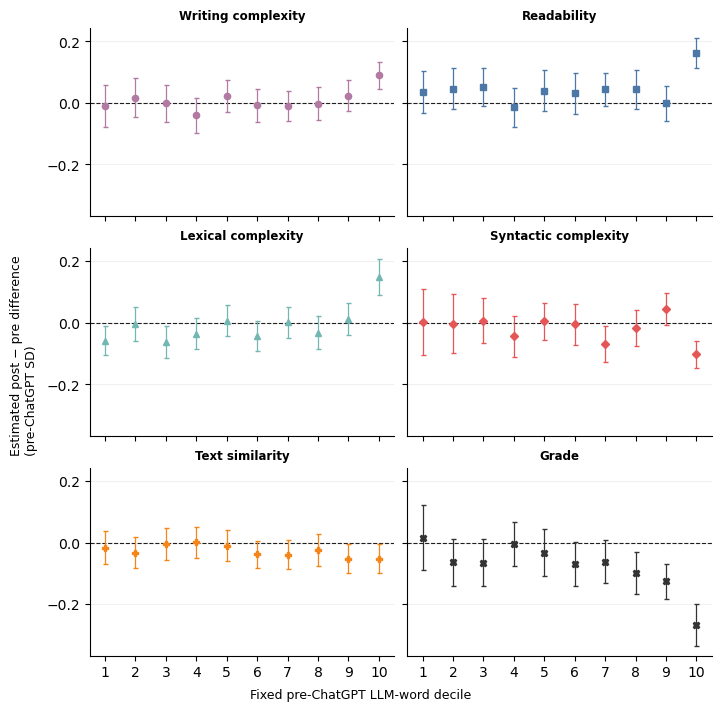

In [16]:
# ================================================================
# SI FIGURE:
# CATEGORICAL-DECILE MARGINAL POST − PRE DIFFERENCES
# ================================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(7.1, 7.0),
    sharex=True,
    sharey=True,
    layout="constrained",
)

axes = axes.flatten()


global_low = (
    categorical_margins[
        "ci_low"
    ]
    .min()
)

global_high = (
    categorical_margins[
        "ci_high"
    ]
    .max()
)

padding = (
    global_high
    - global_low
) * 0.06

if padding == 0:
    padding = 0.05


for ax, outcome in zip(
    axes,
    OUTCOME_ORDER,
):

    temp = (
        categorical_margins
        .loc[
            categorical_margins[
                "outcome"
            ]
            == outcome
        ]
        .sort_values(
            "decile"
        )
    )

    x = (
        temp[
            "decile"
        ]
        .to_numpy()
    )

    y = (
        temp[
            "estimate"
        ]
        .to_numpy()
    )

    yerr = np.vstack(
        [
            y
            - temp[
                "ci_low"
            ].to_numpy(),

            temp[
                "ci_high"
            ].to_numpy()
            - y,
        ]
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        zorder=1,
    )

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt=OUTCOME_MARKERS[
            outcome
        ],
        linestyle="none",
        color=OUTCOME_COLORS[
            outcome
        ],
        ecolor=OUTCOME_COLORS[
            outcome
        ],
        markersize=4.5,
        elinewidth=0.9,
        capsize=1.8,
        zorder=3,
    )

    ax.set_title(
        OUTCOMES[
            outcome
        ],
        fontsize=8.5,
        fontweight="bold",
    )

    ax.set_xticks(
        DECILE_GRID
    )

    ax.set_xlim(
        0.5,
        10.5,
    )

    ax.set_ylim(
        global_low
        - padding,
        global_high
        + padding,
    )

    ax.grid(
        axis="y",
        alpha=0.18,
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


fig.supxlabel(
    "Fixed pre-ChatGPT LLM-word decile",
    fontsize=9.0,
)

fig.supylabel(
    (
        "Estimated post − pre difference\n"
        "(pre-ChatGPT SD)"
    ),
    fontsize=9.0,
)


fig.savefig(
    APPENDIX_PATH
    / "SI_categorical_decile_robustness.pdf",
    bbox_inches="tight",
)

fig.savefig(
    APPENDIX_PATH
    / "SI_categorical_decile_robustness.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()


## SI robustness — raw-outcome replication

This section repeats the main linear interaction specification using the stored outcome variables rather than the pre-ChatGPT-standardized versions. Both the resulting plot and regression table are saved to the appendix output folder.

In [17]:
# ================================================================
# RAW-OUTCOME LINEAR INTERACTION MODELS
# ================================================================

raw_models = {}
raw_interaction_rows = []
raw_margin_rows = []


for outcome in OUTCOME_ORDER:

    model = pf.feols(
        (
            f"{outcome} ~ "
            f"after * llm_decile_c "
            f"| {COURSE_COL}"
        ),
        data=analysis_data,
        vcov={
            "CRV1": COURSE_COL
        },
    )

    raw_models[
        outcome
    ] = model

    tidy = (
        model
        .tidy()
    )

    interaction_term = find_interaction_term(
        tidy,
        "after",
        "llm_decile_c",
    )

    row = tidy.loc[
        interaction_term
    ]

    raw_interaction_rows.append(
        {
            "outcome": outcome,
            "label": OUTCOMES[
                outcome
            ],
            "estimate": row[
                "Estimate"
            ],
            "std_error": row[
                "Std. Error"
            ],
            "ci_low": row[
                "2.5%"
            ],
            "ci_high": row[
                "97.5%"
            ],
            "p_value": row[
                "Pr(>|t|)"
            ],
        }
    )


    margins = linear_post_pre_margins(
        model
    )

    margins[
        "outcome"
    ] = outcome

    margins[
        "label"
    ] = OUTCOMES[
        outcome
    ]

    raw_margin_rows.append(
        margins
    )


raw_interactions = pd.DataFrame(
    raw_interaction_rows
)

raw_margins = pd.concat(
    raw_margin_rows,
    ignore_index=True,
)


display(
    raw_interactions
)

display(
    raw_margins
)


,outcome,label,estimate,std_error,ci_low,ci_high,p_value
0,WQ_index_norm,Writing complexity,0.001499,0.000352,0.000807,0.002191,2.489668e-05
1,readability_index_norm,Readability,0.002093,0.000370,0.001366,0.002821,2.719900e-08
2,lexical_index_norm,Lexical complexity,0.002214,0.000387,0.001452,0.002975,1.948952e-08
3,syntactic_index_norm,Syntactic complexity,-0.000891,0.000538,-0.001947,0.000165,9.814395e-02
4,cosine_similarity_full,Text similarity,-0.000853,0.000599,-0.002029,0.000324,1.549457e-01
5,karakter_0_6,Grade,-0.032600,0.005845,-0.044084,-0.021116,4.080673e-08


,decile,estimate,std_error,ci_low,ci_high,outcome,label
0,1,-0.004999,0.002476,-0.009866,-0.000133,WQ_index_norm,Writing complexity
1,2,-0.003500,0.002208,-0.007838,0.000838,WQ_index_norm,Writing complexity
2,3,-0.002001,0.001965,-0.005863,0.001861,WQ_index_norm,Writing complexity
3,4,-0.000501,0.001761,-0.003961,0.002959,WQ_index_norm,Writing complexity
4,5,0.000998,0.001608,-0.002161,0.004158,WQ_index_norm,Writing complexity
5,6,0.002498,0.001523,-0.000494,0.005490,WQ_index_norm,Writing complexity
6,7,0.003997,0.001517,0.001017,0.006977,WQ_index_norm,Writing complexity
7,8,0.005496,0.001590,0.002371,0.008621,WQ_index_norm,Writing complexity
8,9,0.006996,0.001734,0.003589,0.010403,WQ_index_norm,Writing complexity
9,10,0.008495,0.001932,0.004699,0.012291,WQ_index_norm,Writing complexity


## SI Figure — raw-outcome marginal post–pre differences

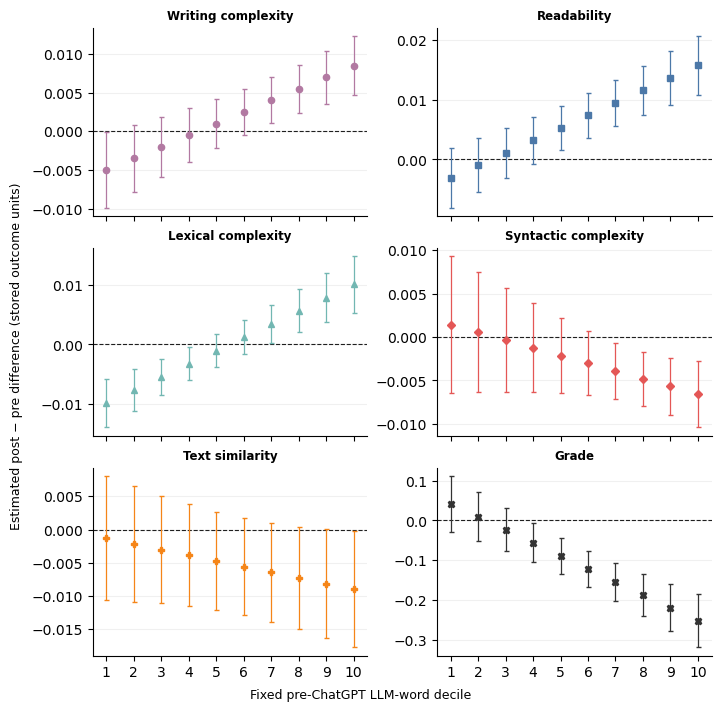

In [18]:
# ================================================================
# SI FIGURE:
# RAW-OUTCOME MARGINAL POST − PRE DIFFERENCES
# ================================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(7.1, 7.0),
    sharex=True,
    layout="constrained",
)

axes = axes.flatten()


for ax, outcome in zip(
    axes,
    OUTCOME_ORDER,
):

    temp = (
        raw_margins
        .loc[
            raw_margins[
                "outcome"
            ]
            == outcome
        ]
        .sort_values(
            "decile"
        )
    )

    x = (
        temp[
            "decile"
        ]
        .to_numpy()
    )

    y = (
        temp[
            "estimate"
        ]
        .to_numpy()
    )

    yerr = np.vstack(
        [
            y
            - temp[
                "ci_low"
            ].to_numpy(),

            temp[
                "ci_high"
            ].to_numpy()
            - y,
        ]
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        zorder=1,
    )

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt=OUTCOME_MARKERS[
            outcome
        ],
        linestyle="none",
        color=OUTCOME_COLORS[
            outcome
        ],
        ecolor=OUTCOME_COLORS[
            outcome
        ],
        markersize=4.5,
        elinewidth=0.9,
        capsize=1.8,
        zorder=3,
    )

    ax.set_title(
        OUTCOMES[
            outcome
        ],
        fontsize=8.5,
        fontweight="bold",
    )

    ax.set_xticks(
        DECILE_GRID
    )

    ax.set_xlim(
        0.5,
        10.5,
    )

    ax.grid(
        axis="y",
        alpha=0.18,
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


fig.supxlabel(
    "Fixed pre-ChatGPT LLM-word decile",
    fontsize=9.0,
)

fig.supylabel(
    "Estimated post − pre difference (stored outcome units)",
    fontsize=9.0,
)


fig.savefig(
    APPENDIX_PATH
    / "SI_raw_outcome_margins.pdf",
    bbox_inches="tight",
)

fig.savefig(
    APPENDIX_PATH
    / "SI_raw_outcome_margins.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()


## SI Table — raw-outcome interaction models

In [19]:
# ================================================================
# SI TABLE:
# RAW-OUTCOME LINEAR INTERACTION MODELS
# ================================================================

raw_model_rows = []


for outcome in OUTCOME_ORDER:

    model = raw_models[
        outcome
    ]

    tidy = (
        model
        .tidy()
    )

    interaction_term = find_interaction_term(
        tidy,
        "after",
        "llm_decile_c",
    )

    term_map = {
        "after": "Post-ChatGPT",
        "llm_decile_c": "LLM-word decile (centered)",
        interaction_term: "Post × LLM-word decile",
    }

    for term, term_label in term_map.items():

        row = tidy.loc[
            term
        ]

        raw_model_rows.append(
            {
                "outcome": outcome,
                "outcome_label": OUTCOMES[
                    outcome
                ],
                "term": term,
                "term_label": term_label,
                "estimate": row[
                    "Estimate"
                ],
                "std_error": row[
                    "Std. Error"
                ],
                "ci_low": row[
                    "2.5%"
                ],
                "ci_high": row[
                    "97.5%"
                ],
                "p_value": row[
                    "Pr(>|t|)"
                ],
                "n": len(
                    analysis_data
                ),
                "n_courses": analysis_data[
                    COURSE_COL
                ].nunique(),
            }
        )


table_s4_long = pd.DataFrame(
    raw_model_rows
)


display(
    table_s4_long
)


table_s4_long.to_csv(
    APPENDIX_PATH
    / "SI_raw_llm_decile_interaction_models.csv",
    index=False,
)


table_s4_wide = (
    table_s4_long
    .assign(
        cell=lambda d: [
            coef_se_cell(
                est,
                se,
            )
            for est, se
            in zip(
                d[
                    "estimate"
                ],
                d[
                    "std_error"
                ],
            )
        ]
    )
    .pivot(
        index="term_label",
        columns="outcome_label",
        values="cell",
    )
)

table_s4_wide = (
    table_s4_wide
    .reindex(
        [
            "Post-ChatGPT",
            "LLM-word decile (centered)",
            "Post × LLM-word decile",
        ]
    )
)

table_s4_wide.loc[
    "Course fixed effects"
] = "Yes"

table_s4_wide.loc[
    "CRV1 clustered by course"
] = "Yes"

table_s4_wide.loc[
    "Observations"
] = f"{len(analysis_data):,}"

table_s4_wide.loc[
    "Courses"
] = f"{analysis_data[COURSE_COL].nunique():,}"


with open(
    APPENDIX_PATH
    / "SI_raw_llm_decile_interaction_models.tex",
    "w",
    encoding="utf-8",
) as f:

    f.write(
        table_s4_wide.to_latex(
            escape=False,
            caption=(
                "Course-fixed-effects models of student outcomes in their "
                "stored Figure 2 units by LLM-associated word-rate decile "
                "and the post-ChatGPT period."
            ),
            label="tab:llm_decile_interactions_raw",
        )
    )


,outcome,outcome_label,term,term_label,estimate,std_error,ci_low,ci_high,p_value,n,n_courses
0,WQ_index_norm,Writing complexity,after,Post-ChatGPT,0.001748,0.001556,-0.001309,0.004805,2.618345e-01,44374,479
1,WQ_index_norm,Writing complexity,llm_decile_c,LLM-word decile (centered),0.009553,0.000292,0.008979,0.010127,0.000000e+00,44374,479
2,WQ_index_norm,Writing complexity,after:llm_decile_c,Post × LLM-word decile,0.001499,0.000352,0.000807,0.002191,2.489668e-05,44374,479
3,readability_index_norm,Readability,after,Post-ChatGPT,0.006343,0.001891,0.002628,0.010059,8.585504e-04,44374,479
4,readability_index_norm,Readability,llm_decile_c,LLM-word decile (centered),0.010442,0.000340,0.009773,0.011111,0.000000e+00,44374,479
5,readability_index_norm,Readability,after:llm_decile_c,Post × LLM-word decile,0.002093,0.000370,0.001366,0.002821,2.719900e-08,44374,479
6,lexical_index_norm,Lexical complexity,after,Post-ChatGPT,0.000070,0.001397,-0.002674,0.002815,9.598544e-01,44374,479
7,lexical_index_norm,Lexical complexity,llm_decile_c,LLM-word decile (centered),0.009909,0.000299,0.009322,0.010497,0.000000e+00,44374,479
8,lexical_index_norm,Lexical complexity,after:llm_decile_c,Post × LLM-word decile,0.002214,0.000387,0.001452,0.002975,1.948952e-08,44374,479
9,syntactic_index_norm,Syntactic complexity,after,Post-ChatGPT,-0.002576,0.002025,-0.006556,0.001403,2.039389e-01,44374,479


## Output inventory

In [20]:
print("MAIN PAPER")
print(
    "  Figure 3 (PDF):",
    PLOT_PATH
    / "gai_figure3_llm_decile_heterogeneity.pdf",
)
print(
    "  Figure 3 (PNG):",
    PLOT_PATH
    / "gai_figure3_llm_decile_heterogeneity.png",
)


print("\nSUPPLEMENTARY INFORMATION — APPENDIX FOLDER")

si_outputs = [
    "SI_llm_decile_construction_composition.pdf",
    "SI_llm_decile_construction_composition.png",
    "SI_llm_decile_construction_composition.csv",
    "SI_llm_decile_construction_composition.tex",
    "SI_standardized_llm_decile_interaction_models.csv",
    "SI_standardized_llm_decile_interaction_models.tex",
    "SI_standardized_margins_by_llm_decile.csv",
    "SI_standardized_margins_by_llm_decile.tex",
    "SI_categorical_decile_margins_data.csv",
    "SI_categorical_decile_robustness.pdf",
    "SI_categorical_decile_robustness.png",
    "SI_raw_outcome_margins.pdf",
    "SI_raw_outcome_margins.png",
    "SI_raw_llm_decile_interaction_models.csv",
    "SI_raw_llm_decile_interaction_models.tex",
]

for filename in si_outputs:
    print(
        " ",
        APPENDIX_PATH
        / filename,
    )

MAIN PAPER
  Figure 3 (PDF): /work/data_assigments/GAI paper/replication/outputs/figures/gai_figure3_llm_decile_heterogeneity.pdf
  Figure 3 (PNG): /work/data_assigments/GAI paper/replication/outputs/figures/gai_figure3_llm_decile_heterogeneity.png

SUPPLEMENTARY INFORMATION — APPENDIX FOLDER
  /work/data_assigments/GAI paper/replication/outputs/appendix/SI_llm_decile_construction_composition.pdf
  /work/data_assigments/GAI paper/replication/outputs/appendix/SI_llm_decile_construction_composition.png
  /work/data_assigments/GAI paper/replication/outputs/appendix/SI_llm_decile_construction_composition.csv
  /work/data_assigments/GAI paper/replication/outputs/appendix/SI_llm_decile_construction_composition.tex
  /work/data_assigments/GAI paper/replication/outputs/appendix/SI_standardized_llm_decile_interaction_models.csv
  /work/data_assigments/GAI paper/replication/outputs/appendix/SI_standardized_llm_decile_interaction_models.tex
  /work/data_assigments/GAI paper/replication/outputs/ap